# CNN Baseline

Entraînement d'un ResNet18 sur le dataset Epic & CSCR (4 classes : glioma, meningioma, notumor, pituitary).

**Rôle dans le pipeline :** modèle de référence déterministe - ses performances servent de baseline pour évaluer l'apport du BNN multimodal (notebook 03) et ses features visuelles sont comparées via Grad-CAM (notebook 05).

**Sortie :** `runs_cnn_baseline/best_final.pt` - utilisé par les notebooks 03 et 05.

### Imports & seed 

In [14]:
import os, random, re
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms, models
from sklearn.metrics import (roc_auc_score, confusion_matrix,
                             balanced_accuracy_score, classification_report)
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("mps" if torch.backends.mps.is_available() else
                      "cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: mps


### Chemins & hyperparamètres

In [15]:
DATAROOT    = "/Users/teodul/Documents/Memoire/Epic and CSCR hospital Dataset"
TRAIN_DIR   = os.path.join(DATAROOT, "Train")
TEST_DIR    = os.path.join(DATAROOT, "Test")
SAVE_DIR    = "runs_cnn_baseline"
os.makedirs(SAVE_DIR, exist_ok=True)

IMG_SIZE    = 224
BATCH_SIZE  = 32
EPOCHS      = 10
LR          = 1e-4
NUM_WORKERS = 0
PATIENCE    = 3

### Transforms

In [16]:
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

### Datasets & loaders

In [ ]:
from torch.utils.data import Subset

train_full_aug = datasets.ImageFolder(TRAIN_DIR, transform=train_tf)
train_full_val = datasets.ImageFolder(TRAIN_DIR, transform=val_tf)
test_ds        = datasets.ImageFolder(TEST_DIR,  transform=val_tf)

def get_patient_id(filepath):
    fname = os.path.basename(filepath)
    m = re.match(r'^(?:Tr|Te)-([a-z]{2}_\d+)', fname)
    if m: return m.group(1)
    m = re.match(r'^([A-Z]_\d+)_', fname)
    if m: return m.group(1)
    m = re.match(r'^([A-Z]_\d+)\.', fname)
    if m: return m.group(1)
    m = re.match(r'^(\d+)', fname)
    if m: return m.group(1)
    return fname

# quelques fichiers n'ont pas de pattern de nom reconnaissable, chacun compte comme un patient unique
unmatched = [os.path.basename(p) for p, _ in train_full_aug.samples
             if get_patient_id(p) == os.path.basename(p)]
print(f"Fichiers fallback (1 img/patient) : {len(unmatched)} / {len(train_full_aug.samples)}")

train_idx, val_idx = [], []
rng = np.random.default_rng(SEED)

for class_name, class_idx in train_full_aug.class_to_idx.items():
    cls_indices = [i for i, (_, y) in enumerate(train_full_aug.samples) if y == class_idx]
    patient_ids = [get_patient_id(train_full_aug.samples[i][0]) for i in cls_indices]
    unique_patients = sorted(set(patient_ids))

    rng.shuffle(unique_patients)
    n_val_p = max(1, int(0.15 * len(unique_patients)))
    val_patients = set(unique_patients[:n_val_p])

    for i, pid in zip(cls_indices, patient_ids):
        (val_idx if pid in val_patients else train_idx).append(i)

train_ds = Subset(train_full_aug, train_idx)
val_ds   = Subset(train_full_val, val_idx)

print("Classes:", train_full_aug.classes)
print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

labels        = [train_full_aug.targets[i] for i in train_idx]
counts        = np.bincount(labels)
print("Counts train:", dict(zip(train_full_aug.classes, counts)))

# inverse de la fréquence de classe → les classes rares ont plus de poids
class_weights  = 1.0 / counts
sample_weights = class_weights[labels]
g_gen = torch.Generator(); g_gen.manual_seed(SEED)
sampler = WeightedRandomSampler(
    torch.tensor(sample_weights, dtype=torch.double),
    num_samples=len(sample_weights), replacement=True
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                          sampler=sampler, num_workers=NUM_WORKERS, generator=g_gen)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS)

Fichiers fallback (1 img/patient) : 970 / 9650
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Train: 8108 | Val: 1542 | Test: 2414
Counts train: {'glioma': 2537, 'meningioma': 1822, 'notumor': 1647, 'pituitary': 2102}


### Modèle ResNet18

In [18]:
NUM_CLASSES = 4

model = models.resnet18(weights="IMAGENET1K_V1")
model.fc = nn.Sequential(
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, NUM_CLASSES)
)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

print(f"Params entraînables : {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Params entraînables : 11,308,868


### Évaluation

In [19]:
@torch.no_grad()
def evaluate(loader, model, split="Test"):
    model.eval()
    all_y, all_preds, all_probs = [], [], []

    for x, y in loader:
        x = x.to(device)
        logits = model(x)
        probs  = torch.softmax(logits, dim=1).cpu().numpy()
        preds  = logits.argmax(dim=1).cpu().numpy()
        all_y.extend(y.numpy())
        all_preds.extend(preds)
        all_probs.extend(probs)

    all_y     = np.array(all_y)
    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)

    bal_acc = balanced_accuracy_score(all_y, all_preds)
    auc     = roc_auc_score(all_y, all_probs, multi_class="ovr", average="macro")
    cm      = confusion_matrix(all_y, all_preds)

    ds = loader.dataset
    classes = ds.classes if hasattr(ds, "classes") else ds.dataset.classes

    print(f"\n[{split}] bal_acc={bal_acc:.3f}  AUC={auc:.3f}")
    print("Confusion matrix:\n", cm)
    print(classification_report(all_y, all_preds,
                                 target_names=classes, digits=3))
    return bal_acc, auc

### Boucle d'entraînement + early stopping

In [20]:
history    = {"loss": [], "val_bal_acc": [], "val_auc": []}
best_auc   = -1.0
no_improve = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    losses = []

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

    scheduler.step()
    print(f"\nepoch {epoch:02d}/{EPOCHS}  loss={np.mean(losses):.4f}")
    bal_acc, auc = evaluate(val_loader, model, split="Val")

    history["loss"].append(np.mean(losses))
    history["val_bal_acc"].append(bal_acc)
    history["val_auc"].append(auc)

    if auc > best_auc:
        best_auc   = auc
        no_improve = 0
        torch.save({
            "epoch": epoch,
            "auc": auc,
            "bal_acc": bal_acc,
            "model_state": model.state_dict(),
            "classes": train_full_aug.classes,
            "img_size": IMG_SIZE,
        }, f"{SAVE_DIR}/best_final.pt")
        print(f"  ✓ saved (AUC val={auc:.3f})")
    else:
        no_improve += 1
        print(f"  patience {no_improve}/{PATIENCE}")
        if no_improve >= PATIENCE:
            print(f"Early stopping à l'epoch {epoch}")
            break

print(f"\nMeilleur AUC val : {best_auc:.3f}")
print(f"Modèle sauvegardé : {SAVE_DIR}/best_final.pt")


epoch 01/10  loss=0.3113

[Val] bal_acc=0.963  AUC=0.995
Confusion matrix:
 [[464  10   7   0]
 [ 14 334   9   4]
 [  1   0 295   2]
 [  4   4   3 391]]
              precision    recall  f1-score   support

      glioma      0.961     0.965     0.963       481
  meningioma      0.960     0.925     0.942       361
     notumor      0.939     0.990     0.964       298
   pituitary      0.985     0.973     0.979       402

    accuracy                          0.962      1542
   macro avg      0.961     0.963     0.962      1542
weighted avg      0.963     0.962     0.962      1542

  ✓ saved (AUC val=0.995)

epoch 02/10  loss=0.1077

[Val] bal_acc=0.949  AUC=0.996
Confusion matrix:
 [[463   5  12   1]
 [ 16 316   5  24]
 [  1   0 297   0]
 [  2   0  13 387]]
              precision    recall  f1-score   support

      glioma      0.961     0.963     0.962       481
  meningioma      0.984     0.875     0.927       361
     notumor      0.908     0.997     0.950       298
   pituitary  

### Évaluation sur le test set

In [ ]:
ckpt = torch.load(f"{SAVE_DIR}/best_final.pt", map_location=device, weights_only=False)
model.load_state_dict(ckpt["model_state"])
print(f"Meilleur modèle chargé : epoch {ckpt['epoch']}, AUC val={ckpt['auc']:.3f}")
print("\n--- Évaluation finale sur le test set ---")
evaluate(test_loader, model, split="Test")

Meilleur modèle chargé : epoch 8, AUC val=0.999

--- Évaluation finale sur le test set ---

[Test] bal_acc=0.976  AUC=0.997
Confusion matrix:
 [[710  29  14   2]
 [  8 528   1   9]
 [  1   0 486   0]
 [  0   1   0 625]]
              precision    recall  f1-score   support

      glioma      0.987     0.940     0.963       755
  meningioma      0.946     0.967     0.957       546
     notumor      0.970     0.998     0.984       487
   pituitary      0.983     0.998     0.990       626

    accuracy                          0.973      2414
   macro avg      0.972     0.976     0.974      2414
weighted avg      0.973     0.973     0.973      2414



(0.9759448714616346, 0.9965963736577809)

### Courbes

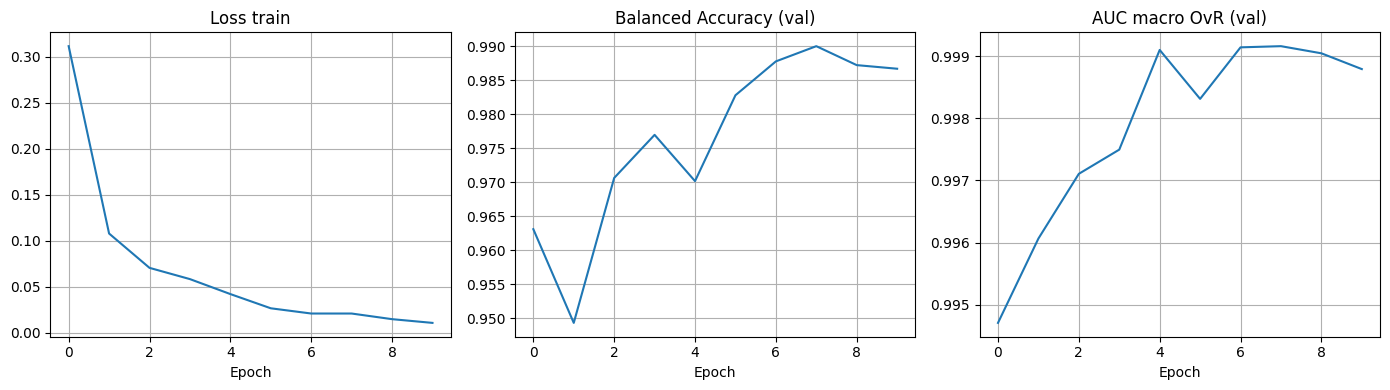

Figures sauvegardées dans runs_cnn_baseline


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].plot(history["loss"]);        axes[0].set_title("Loss train")
axes[1].plot(history["val_bal_acc"]); axes[1].set_title("Balanced Accuracy (val)")
axes[2].plot(history["val_auc"]);     axes[2].set_title("AUC macro OvR (val)")
for ax in axes:
    ax.set_xlabel("Epoch")
    ax.grid(True)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/curves.png", dpi=150)
plt.show()
print("Figures sauvegardées dans", SAVE_DIR)